# **Portfolio Allocation with a Carbon Objective**

**Course:** Sustainability Aware Asset Management  
**Semester:** Spring 2025–2026  

**Authors:**

- Alessandro Botti  
- Yoann Klingele  
- Charbel Merhi  
- Andrea Perani  

This notebook implements the empirical analysis for the *Sustainability Aware Asset Management* project.

The objective is to construct and evaluate portfolio allocation strategies using financial data and carbon emissions information.

## **Reproducibility**

To reproduce the analysis, please follow the steps below:

- Clone the project repository locally.

- Create the Python environment:

```bash
conda env create -f environment.yml
```

- Activate the environment:

```bash
conda activate saam-project
```

- Select the newly created kernel in the notebook.

- Run all cells sequentially from top to bottom.

## **Part I – Standard Portfolio Allocation**

The first part of the project consists of building a portfolio based on the **minimum-variance criterion** and comparing its performance with a **value-weighted benchmark portfolio**.

In [17]:
import pandas as pd
import numpy as np

# Path to the cleaned datasets
path = "../data/cleaned/"

# Load cleaned datasets
ri_m = pd.read_csv(path + "RI_M_cleaned.csv", sep=";", na_values="N/A")
co2 = pd.read_csv(path + "CO2_S1_cleaned.csv", sep=";", na_values="N/A")
static = pd.read_csv(path + "STATIC_cleaned.csv", sep=";", na_values="N/A")

## 1) Data Cleaning

Data cleaning is necessary to construct a meaningful and implementable investment strategy.

The datasets used in this notebook correspond to cleaned versions of the original Datastream files. The cleaning procedure follows the guidelines provided in the project description and was partly conducted manually in Excel.

The main steps applied during the manual cleaning phase are summarized below:

- **Removal of completely missing firms**  
  Some ISIN codes returned no data in the Datastream output (for example due to incorrect share classes or missing carbon information). Firms with no available observations across the datasets were removed so that all tables contain the same set of companies.

- **Treatment of very low prices in the Return Index**  
  In the total return index datasets (monthly and yearly), prices below **0.5** were treated as missing values. Extremely low prices can generate unrealistic or infinite returns when computing percentage changes.

- **Treatment of delistings**  
  When firms are delisted, Datastream typically reports missing values at the end of the sample.  
  To capture the economic effect of delisting, the following rule was applied in the return index datasets:

  - the first missing observation after the last valid price is replaced with **0**
  - all subsequent observations remain *N/A*

  This ensures that the return in the delisting period corresponds to **−100%**, reflecting the loss experienced by investors.

- **Handling missing values within the sample**  
  For annual variables such as **revenues** and **CO₂ emissions**, missing observations between two available years were replaced with the previous available value (forward fill). This assumption reflects delayed or incomplete reporting.

- **Accounting variables left unchanged**  
  Accounting variables such as revenues were **not set to zero when firms delist**. Missing accounting data remain recorded as *N/A*, since a delisting event does not necessarily imply that the firm’s revenues fall to zero.

The datasets directly modified during the cleaning process are mainly the **total return index datasets (RI_M and RI_Y)**, while other datasets remain unchanged except for the forward filling of annual reporting gaps.

After these operations, the datasets contain a consistent set of firms and are suitable for the subsequent portfolio construction steps.

The table below reports the number of firms remaining after these initial cleaning operations.

In [18]:
print("static shape:", static.shape)
pd.concat([static.head(), static.tail()])

static shape: (618, 4)


,ISIN,NAME,Country,Region
0,AT000000STR1,STRABAG SE,AT,EUR
1,AT00000VIE62,FLUGHAFEN WIEN,AT,EUR
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR
3,AT0000652011,ERSTE GROUP BANK,AT,EUR
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR
613,SE0020050417,BOLIDEN ORD SHS,SE,EUR
614,US0528001094,AUTOLIV,SE,EUR
615,US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,IL,EUR
616,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,IL,EUR
617,US91822M5022,VEON ADR 1:25,NL,EUR


Some additional data issues are addressed later when constructing the investment set. These include:

- **Stale prices**  
  Some securities may exhibit long periods with unchanged prices due to illiquidity or lack of trading activity.

- **Insufficient return history**  
  Firms with too few available monthly return observations cannot be used to estimate reliable return moments.

- **Carbon data availability**  
  Since the second part of the project introduces carbon constraints, firms without carbon information must be excluded from the investment universe.

- **Investment time horizon**  
  Portfolio allocation starts in **2014**, after using the period **2004–2013** to estimate expected returns and the covariance matrix.

These aspects are addressed in **Section 2.1**, where the investment universe is formally defined.

A more detailed description of the complete cleaning procedure is provided in the report.

Before proceeding with the empirical analysis, we verify that the cleaned datasets contain the same number of firms and reorganize the matrices into a format that is more suitable for portfolio construction.

Note that the CO₂ dataset includes observations for **2025**. These values are retained for carry-forward purposes when computing carbon intensities, but they are not used to construct portfolio allocations for **2026**, since the corresponding monthly return data are not available.

In [19]:
print("co2 shape:", co2.shape)
co2.head()

co2 shape: (618, 29)


,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246,876651,844209,833816,742063,771799,813242,819934,790336,790336
1,FLUGHAFEN WIEN,AT00000VIE62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796,8455,8958,9648,4745,5663,7567,9027,9847,9847
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027,6270,7696,7455,6392,4827,6049,12403,9375,9375
3,ERSTE GROUP BANK,AT0000652011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630,27967,27297,29950,24929,21530,20707,18701,16803,16803
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14813,3",...,27419,27867,23833,22758,23766,23732,24048,20964,18807,18807


In [20]:
# Read the year labels and convert them to integers
years = pd.to_numeric(co2.columns[2:], errors="raise").astype(int)

# Create a copy of the dataset and assign year labels to the columns
co2_wide = co2.copy()
co2_wide.columns = ["NAME", "ISIN"] + list(years)

# Use ISIN and NAME as identifiers and sort the columns by year
co2_wide = co2_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

# Convert co2 values to numeric format
co2_wide = co2_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("co2_wide shape:", co2_wide.shape)
pd.concat([co2_wide.head(), co2_wide.tail()])

co2_wide shape: (618, 27)


,,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246.0,876651.00,844209.00,833816.0,742063.0,771799.00,813242.0,819934.0,790336.0,790336.0
AT00000VIE62,FLUGHAFEN WIEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796.0,8455.00,8958.00,9648.0,4745.0,5663.00,7567.0,9027.0,9847.0,9847.0
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027.0,6270.00,7696.00,7455.0,6392.0,4827.00,6049.0,12403.0,9375.0,9375.0
AT0000652011,ERSTE GROUP BANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630.0,27967.00,27297.00,29950.0,24929.0,21530.00,20707.0,18701.0,16803.0,16803.0
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14813.3,29430.22,16027.64,...,27419.0,27867.00,23833.00,22758.0,23766.0,23732.00,24048.0,20964.0,18807.0,18807.0
SE0020050417,BOLIDEN ORD SHS,NaN,NaN,NaN,NaN,NaN,NaN,703000.0,189936.0,413000.00,473000.00,...,594000.0,605000.00,644000.00,598000.0,544000.0,624794.00,629000.0,627845.0,657646.0,657646.0
US0528001094,AUTOLIV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102103.61,119092.85,107000.0,98000.0,103000.00,102000.0,95000.0,75000.0,75000.0
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13392.0,13392.00,5170.00,4833.0,3854.0,4238.28,4569.0,4569.0,4569.0,4569.0
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,392268.0,458755.00,372604.00,299146.0,290471.0,282044.00,253306.0,242056.0,243603.0,243603.0


In [21]:
print("ri_m shape:", ri_m.shape)
ri_m.head()

ri_m shape: (618, 316)


,NAME,ISIN,31/12/99,31/01/00,29/02/00,31/03/00,28/04/00,31/05/00,30/06/00,31/07/00,...,30/04/25,30/05/25,30/06/25,31/07/25,29/08/25,30/09/25,31/10/25,28/11/25,31/12/25,30/01/26
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"430,27","430,83","479,46","477,35","465,06","461,5","396,65","452,87","481,49","526,88"
1,FLUGHAFEN WIEN,AT00000VIE62,"147,79","156,25","153,83","158,62","137,27","148,95","159,68","151,08",...,"2339,19","2371,03","2478,96","2417,14","2434,84","2425,66","2409,99","2533,4","2591,68","2587,67"
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"113,07","129,28","128,7","123,36","140,73","146,05","158,13","171,78","190,56","215,11"
3,ERSTE GROUP BANK,AT0000652011,"102,94","94,91","97,74","100,5","96,13","97,86","102,06","102,43",...,"1237,75","1536,73","1621,45","1761,42","1818,07","1867,75","1979,03","2087,48","2308,86","2488,84"
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"343,5","359,25","383,12","360,02","370,54","361,64","360,3","350,11","357,49","360,93"


In [22]:
# Convert the column labels into datetime format
dates = pd.to_datetime(ri_m.columns[2:], format="%d/%m/%y", errors="coerce")

# Create a copy of the return index dataset and assign the date labels
ri_m_wide = ri_m.copy()
ri_m_wide.columns = ["NAME", "ISIN"] + list(dates)

# Use ISIN and NAME as identifiers and sort the columns by date
ri_m_wide = ri_m_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

# Transform the return index values into numeric format
ri_m_wide = ri_m_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("ri_m_wide shape:", ri_m_wide.shape)
pd.concat([ri_m_wide.head(), ri_m_wide.tail()])

ri_m_wide shape: (618, 314)


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.27,430.83,479.46,477.35,465.06,461.50,396.65,452.87,481.49,526.88
AT00000VIE62,FLUGHAFEN WIEN,147.79,156.25,153.83,158.62,137.27,148.95,159.68,151.08,153.35,161.64,...,2339.19,2371.03,2478.96,2417.14,2434.84,2425.66,2409.99,2533.40,2591.68,2587.67
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,113.07,129.28,128.70,123.36,140.73,146.05,158.13,171.78,190.56,215.11
AT0000652011,ERSTE GROUP BANK,102.94,94.91,97.74,100.50,96.13,97.86,102.06,102.43,106.82,102.31,...,1237.75,1536.73,1621.45,1761.42,1818.07,1867.75,1979.03,2087.48,2308.86,2488.84
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,343.50,359.25,383.12,360.02,370.54,361.64,360.30,350.11,357.49,360.93
SE0020050417,BOLIDEN ORD SHS,16.00,15.72,11.76,11.49,8.90,8.70,7.67,6.87,5.99,5.73,...,37.21,37.84,37.53,37.37,41.71,49.32,54.77,58.06,67.73,85.79
US0528001094,AUTOLIV,85.34,77.68,79.83,87.89,82.58,80.52,70.78,71.70,68.13,57.61,...,678.86,753.90,820.48,817.91,909.71,911.70,862.24,877.52,882.80,901.69
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,159.82,113.50,105.00,102.69,66.01,44.01,58.68,48.64,58.68,47.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,1649.72,1506.25,1985.68,1718.26,2027.13,2483.16,2555.90,2801.43,2796.27,3376.35,...,3867.12,4183.76,4178.77,3852.16,4582.69,5036.47,5106.29,6704.49,7781.60,8497.18


## 2) Minimum-Variance Portfolio Allocation

The return index values are converted into returns using the simple return definition, $R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1$.

Returns at date *t* are then collected in the vector $R_t = (R_{1,t}, \ldots, R_{N,t})$, where $N$ denotes the number of firms.

In [23]:
# Convert return index values into simple returns by computing percentage changes over time
returns_wide = ri_m_wide.pct_change(axis=1, fill_method=None)

print("returns_wide shape:", returns_wide.shape)
pd.concat([returns_wide.head(), returns_wide.tail()])

returns_wide shape: (618, 314)


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,FLUGHAFEN WIEN,NaN,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
AT0000652011,ERSTE GROUP BANK,NaN,-0.078007,0.029818,0.028238,-0.043483,0.017996,0.042918,0.003625,0.042859,-0.042221,...,-0.018134,0.241551,0.055130,0.086324,0.032162,0.027326,0.059580,0.054800,0.106051,0.077952
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135199,0.045852,0.066444,-0.060294,0.029221,-0.024019,-0.003705,-0.028282,0.021079,0.009623
SE0020050417,BOLIDEN ORD SHS,NaN,-0.017500,-0.251908,-0.022959,-0.225413,-0.022472,-0.118391,-0.104302,-0.128093,-0.043406,...,-0.057736,0.016931,-0.008192,-0.004263,0.116136,0.182450,0.110503,0.060069,0.166552,0.266647
US0528001094,AUTOLIV,NaN,-0.089759,0.027678,0.100965,-0.060416,-0.024946,-0.120964,0.012998,-0.049791,-0.154411,...,0.054049,0.110538,0.088314,-0.003132,0.112237,0.002188,-0.054250,0.017721,0.006017,0.021398
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,-0.289826,-0.074890,-0.022000,-0.357192,-0.333283,0.333333,-0.171097,0.206414,-0.190866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,-0.086966,0.318294,-0.134674,0.179757,0.224963,0.029293,0.096064,-0.001842,0.207448,...,0.009110,0.081880,-0.001193,-0.078159,0.189642,0.099020,0.013863,0.312987,0.160655,0.091958


### 2.1) Investment Set

This section defines the investment sets used to construct the out-of-sample portfolios.

The allocation exercise is carried out from the end of **2013** to the end of **2024**.

At the end of each year (**Y**), the investment set is defined as the set of firms that satisfy the following criteria:

- **Sufficient return history**  
  Firms must have enough monthly return observations to estimate expected returns and the covariance matrix. In this notebook, we require at least **3 years of available monthly returns** over the previous **10-year estimation window**.

- **No stale prices**  
  Firms are excluded if the share of zero monthly returns, computed over the available observations in the estimation window, exceeds **50%**.

- **Carbon data availability**  
  Since the second part of the project introduces carbon constraints, only firms with carbon data available at the end of year **Y** are retained.

- **Valid December return index observation**  
  Firms must have a valid return index observation at the end of **December of year Y**, so that they can enter the allocation for year **Y + 1**.

If a firm does not satisfy these criteria at the end of year **Y**, it is excluded from that year’s investment set.

The table below reports the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix.

In [24]:
# Rebalancing years: portfolios are formed from end-2013 to end-2024
years = range(2013, 2025)

# Main parameters used to define the investment set
tau = 120              # 10 years of monthly returns
min_obs = 36           # at least 3 years of available monthly returns
stale_threshold = 0.50 # maximum 50% of zero returns among available observations

# Keep only firms that are present in the price and carbon panels used later in the analysis
common_firms = ri_m_wide.index.intersection(co2_wide.index)

ri_panel = ri_m_wide.loc[common_firms].copy()
co2_panel = co2_wide.loc[common_firms].copy()

# Pre-compute monthly returns from the RI panel
ret_panel = ri_panel.pct_change(axis=1, fill_method=None)
ret_panel = ret_panel.replace([np.inf, -np.inf], np.nan)

# Store the December date associated with each formation year
year_end_dec = {}

for Y in years:
    dec_dates = [d for d in ri_panel.columns if d.year == Y and d.month == 12]
    if len(dec_dates) == 0:
        raise ValueError(f"No December date found for year {Y}")
    year_end_dec[Y] = max(dec_dates)

# Build a 120-return estimation window ending in December of year Y
# The window is selected by column position rather than calendar subtraction,
# because the RI dates correspond to trading month-end observations
def get_return_window(panel, end_date, n_returns=120):
    end_loc = panel.columns.get_loc(end_date)

    # We need 121 price observations to obtain 120 returns
    start_loc = end_loc - n_returns
    if start_loc < 0:
        raise ValueError(f"Not enough price history before {end_date}")

    price_cols = panel.columns[start_loc:end_loc + 1]
    price_window = panel.loc[:, price_cols]

    return_window = price_window.pct_change(axis=1, fill_method=None)
    return_window = return_window.replace([np.inf, -np.inf], np.nan)

    # Drop the first column, which is missing by construction
    return_window = return_window.iloc[:, 1:]

    return return_window

# Build covariance using pairwise correlation on the common overlap
# and each asset's own full-window standard deviation
def compute_cov_matrix(est_window):
    # Use sample standard deviation (ddof=1)
    asset_std = est_window.std(axis=1, ddof=1)

    # Pairwise correlation on the common overlap
    corr_matrix = est_window.T.corr()

    # Reconstruct covariance matrix
    sigma = corr_matrix.mul(asset_std, axis=0).mul(asset_std, axis=1).copy()

    # Set the diagonal equal to each asset's own sample variance
    diag_values = asset_std.pow(2)
    for i, asset in enumerate(sigma.index):
        sigma.iat[i, i] = diag_values.loc[asset]

    return sigma

# Define a common investment-set rule for all subsequent sections
def get_investment_set(Y):

    dec_date = year_end_dec[Y]

    # 120 monthly returns ending in December of year Y
    returns_window = get_return_window(ri_panel, dec_date, n_returns=tau)

    # 1) Sufficient return history
    n_available = returns_window.notna().sum(axis=1)
    enough_history = n_available >= min_obs

    # 2) No excessive share of zero returns
    zero_counts = returns_window.eq(0).sum(axis=1)
    zero_share = zero_counts / n_available.replace(0, np.nan)
    not_stale = zero_share <= stale_threshold

    # 3) Carbon data available at the end of year Y
    if Y in co2_panel.columns:
        has_carbon = co2_panel[Y].notna()
    else:
        has_carbon = pd.Series(False, index=co2_panel.index)

    # 4) Valid return index observation in December of year Y
    valid_dec_price = ri_panel[dec_date].notna()

    keep = enough_history & not_stale & has_carbon & valid_dec_price

    return common_firms[keep.fillna(False)]

# Store the yearly investment sets and the corresponding estimation inputs
investment_sets = {}
mu_dict = {}
sigma_dict = {}

for Y in years:

    # Select the firms eligible for year Y
    eligible = get_investment_set(Y)
    dec_date = year_end_dec[Y]

    # Extract the estimation window for the eligible firms
    est_window = get_return_window(ri_panel.loc[eligible], dec_date, n_returns=tau)

    # Store the investment set
    investment_sets[Y] = eligible

    # Estimate expected returns and covariance matrix from the selected window
    mu_dict[Y] = est_window.mean(axis=1)
    sigma_dict[Y] = compute_cov_matrix(est_window)

The table below reports the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix.

In [25]:
summary_table = pd.DataFrame({
    "Number of firms": {Y: len(investment_sets[Y]) for Y in years},
    "Expected return vector": {Y: mu_dict[Y].shape for Y in years},
    "Covariance matrix": {Y: sigma_dict[Y].shape for Y in years},
})

summary_table

,Number of firms,Expected return vector,Covariance matrix
2013,477,"(477,)","(477, 477)"
2014,493,"(493,)","(493, 493)"
2015,509,"(509,)","(509, 509)"
2016,515,"(515,)","(515, 515)"
2017,529,"(529,)","(529, 529)"
2018,549,"(549,)","(549, 549)"
2019,574,"(574,)","(574, 574)"
2020,593,"(593,)","(593, 593)"
2021,600,"(600,)","(600, 600)"
2022,592,"(592,)","(592, 592)"


Overall, the size of the investment set increases over most of the sample period, reflecting improved data availability over time, before declining slightly in the final years.

The outputs below report the estimated expected return vectors for **2013** and **2024**, corresponding to the first and last portfolio formation years.

In [26]:
mu_dict[2013]

ISIN          NAME                                        
AT000000STR1  STRABAG SE                                     -0.000342
AT0000606306  RAIFFEISEN BANK INTL.                           0.009210
AT0000652011  ERSTE GROUP BANK                                0.013121
AT0000720008  TELEKOM AUSTRIA                                 0.003181
AT0000743059  OMV                                             0.017857
                                                                ...   
SE0018012635  WIHLBORGS FASTIGHETER                           0.017928
SE0020050417  BOLIDEN ORD SHS                                 0.026865
US70211M1099  PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23    0.011928
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1          0.005449
US91822M5022  VEON ADR 1:25                                   0.005762
Length: 477, dtype: float64

In [27]:
mu_dict[2024]

ISIN          NAME                                  
AT000000STR1  STRABAG SE                                0.013637
AT00000VIE62  FLUGHAFEN WIEN                            0.011278
AT0000606306  RAIFFEISEN BANK INTL.                     0.011045
AT0000652011  ERSTE GROUP BANK                          0.016418
AT0000720008  TELEKOM AUSTRIA                           0.007144
                                                          ...   
SE0018012635  WIHLBORGS FASTIGHETER                     0.012680
SE0020050417  BOLIDEN ORD SHS                           0.013173
US0528001094  AUTOLIV                                   0.008381
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1    0.002201
US91822M5022  VEON ADR 1:25                             0.009034
Length: 564, dtype: float64

The outputs below report the covariance matrices for the first five firms in the **2013** and **2024** investment sets.

In [32]:
sigma_dict[2013].iloc[:5, :5]

,ISIN,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059
,NAME,STRABAG SE,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,OMV
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.020084,0.014374,0.014851,0.006144,0.008677
AT0000606306,RAIFFEISEN BANK INTL.,0.014374,0.020598,0.016882,0.005636,0.008550
AT0000652011,ERSTE GROUP BANK,0.014851,0.016882,0.020279,0.005071,0.007409
AT0000720008,TELEKOM AUSTRIA,0.006144,0.005636,0.005071,0.007344,0.004317
AT0000743059,OMV,0.008677,0.008550,0.007409,0.004317,0.010940


In [33]:
sigma_dict[2024].iloc[:5, :5]

,ISIN,AT000000STR1,AT00000VIE62,AT0000606306,AT0000652011,AT0000720008
,NAME,STRABAG SE,FLUGHAFEN WIEN,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.004714,0.002675,0.003750,0.003614,0.001431
AT00000VIE62,FLUGHAFEN WIEN,0.002675,0.005991,0.003409,0.003485,0.001471
AT0000606306,RAIFFEISEN BANK INTL.,0.003750,0.003409,0.012837,0.008046,0.003132
AT0000652011,ERSTE GROUP BANK,0.003614,0.003485,0.008046,0.010276,0.002417
AT0000720008,TELEKOM AUSTRIA,0.001431,0.001471,0.003132,0.002417,0.003131


### 2.2) Minimum-Variance Portfolio Allocation

This section implements the long-only minimum-variance portfolio for each portfolio formation year.

At the end of year **Y**, the covariance matrix is estimated using the corresponding **120-month estimation window** defined in **Section 2.1**. The portfolio weights are then obtained by solving a constrained minimum-variance problem under **full investment** and **non-negativity** constraints.

The resulting portfolio is held out of sample during year **Y + 1**. Within the year, weights are updated passively according to asset returns. In addition, the cleaned return index data are used to detect delisting events, so that the first missing month following the last valid observation is treated as a **−100% return**, consistently with the cleaning rules described earlier.

The outputs of this section include the yearly investment set sizes, the portfolio weights, the out-of-sample monthly return series, and the main summary statistics of the minimum-variance strategy.


In [34]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from scipy.optimize import minimize

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Section 2.2 uses the objects created in Section 2.1
required_objects = ["years", "investment_sets", "year_end_dec", "ri_panel", "ret_panel", "sigma_dict"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Section 2.1 must be run first. Missing object: {obj}")

# Define input and output paths
data_dir = Path("../data/cleaned")
rf_file = data_dir / "RF.csv"

output_dir = Path("../results/outputs_minvar")
output_dir.mkdir(parents=True, exist_ok=True)

# Set numerical options for the optimization
ridge = 1e-8
solver_maxiter = 2000
ftol = 1e-12
csv_sep = ";"

def solve_minvar(cov_matrix):
    n = cov_matrix.shape[0]

    if n == 0:
        raise ValueError("Covariance matrix is empty.")
    if n == 1:
        return pd.Series([1.0], index=cov_matrix.index)

    Sigma = cov_matrix.to_numpy(dtype=float)
    Sigma = Sigma + ridge * np.eye(n)

    x0 = np.repeat(1 / n, n)

    def objective(w):
        return float(w @ Sigma @ w)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n

    res = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": solver_maxiter, "ftol": ftol, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=cov_matrix.index)
    w = w / w.sum()
    return w

def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()

# Load the risk-free rate series
rf_raw = pd.read_csv(rf_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

if rf_raw.shape[1] < 2:
    raise ValueError("RF.csv must contain at least one date column and one RF column.")

rf = rf_raw.copy()
rf.columns = ["date_code", "RF"]

# Convert the date codes into month-end dates
rf["date_code"] = rf["date_code"].astype(str).str.strip()
rf["date"] = pd.to_datetime(rf["date_code"], format="%Y%m") + pd.offsets.MonthEnd(0)

# Convert risk-free values to numeric format
rf["RF"] = pd.to_numeric(
    rf["RF"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
) / 100.0

rf_series = rf.set_index("date")["RF"].sort_index()
rf_series = rf_series.loc[rf_series.index <= pd.Timestamp("2025-12-31")]

# Convert to decimals if the series is still expressed in percent units
if len(rf_series.dropna()) > 0 and rf_series.dropna().median() > 1:
    rf_series = rf_series / 100.0

# Build a map of delisting event months from the cleaned monthly RI data
# Delisted firms are typically tagged in the NAME field, and the event month corresponds to the first missing RI observation after the last valid one
delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
delist_event_month = {}

for asset in ri_panel.index:
    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date

print(f"Detected {len(delist_event_month)} delisting/suspension event months in RI_M.")

investment_set_rows = []
weights_long_rows = []
oos_rows = []
mv_weights = {}

for Y in years:
    print(f"Formation year {Y} -> OOS year {Y + 1}")

    eligible = investment_sets[Y]
    dec_date = year_end_dec[Y]

    investment_set_rows.append({
        "formation_year": Y,
        "n_eligible": len(eligible)
    })

    if len(eligible) == 0:
        print(f"  Warning: no eligible firms for year {Y}")
        continue

    # Use the covariance matrix already constructed in Section 2.1
    Sigma = sigma_dict[Y].copy()

    # Keep only assets for which the covariance block is fully usable
    valid_assets = Sigma.index[Sigma.notna().all(axis=1)]
    Sigma = Sigma.loc[valid_assets, valid_assets]

    if Sigma.empty:
        print(f"  Warning: covariance matrix is empty for year {Y}")
        continue

    w0 = solve_minvar(Sigma)
    mv_weights[Y] = w0

    for (isin, name), w in w0.items():
        weights_long_rows.append({
            "formation_year": Y,
            "oos_year": Y + 1,
            "ISIN": isin,
            "NAME": name,
            "weight": w
        })

    oos_months = sorted([d for d in ret_panel.columns if d.year == Y + 1])
    if len(oos_months) == 0:
        continue

    current_weights = w0.copy()

    for dt in oos_months:
        r_t = ret_panel.loc[current_weights.index, dt].copy()

        # Apply a -100% return only in the delisting month identified during cleaning
        forced_delist_assets = []
        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        # All other missing returns remain missing observations
        valid = r_t.notna() & current_weights.notna()
        r_t = r_t[valid]
        w_t = current_weights[valid]

        if len(w_t) == 0:
            oos_rows.append({
                "date": dt,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        # Re-normalize the observed weights for the current month
        w_t = w_t / w_t.sum()

        rp_t = float((w_t * r_t).sum())

        oos_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": rp_t
        })

        # Update portfolio weights passively within the year
        denom = 1.0 + rp_t

        if abs(denom) > 1e-12:
            current_weights = w_t * (1.0 + r_t) / denom
            total = current_weights.sum()

            if abs(total) > 1e-12:
                current_weights = current_weights / total
            else:
                current_weights = pd.Series(
                    np.repeat(1 / len(w_t), len(w_t)),
                    index=w_t.index
                )
        else:
            current_weights = pd.Series(
                np.repeat(1 / len(w_t), len(w_t)),
                index=w_t.index
            )

investment_set_sizes = pd.DataFrame(investment_set_rows)
weights_by_year_long = pd.DataFrame(weights_long_rows)

minvar_monthly_returns = pd.DataFrame(oos_rows).sort_values("date").reset_index(drop=True)

if minvar_monthly_returns.empty:
    raise ValueError("No out-of-sample minimum-variance returns were produced.")

minvar_monthly_returns["date"] = pd.to_datetime(minvar_monthly_returns["date"])
minvar_monthly_returns = minvar_monthly_returns[
    (minvar_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (minvar_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

minvar_monthly_returns["cumulative_index"] = (
    1.0 + minvar_monthly_returns["portfolio_return"]
).cumprod()

minvar_cumulative_returns = minvar_monthly_returns[
    ["date", "formation_year", "oos_year", "portfolio_return", "cumulative_index"]
].copy()

full_months = pd.date_range("2014-01-31", "2025-12-31", freq="ME")
template_ready = pd.DataFrame({"date": full_months})
template_ready = template_ready.merge(
    minvar_monthly_returns[["date", "portfolio_return"]],
    on="date",
    how="left"
)
template_ready["date_str"] = template_ready["date"].dt.strftime("%Y-%m")
template_ready = template_ready[["date_str", "portfolio_return"]]

r = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index().dropna()

# Align the risk-free rate and portfolio returns at the monthly frequency
r_month = r.copy()
r_month.index = r_month.index.to_period("M")

rf_month = rf_series.copy()
rf_month.index = rf_month.index.to_period("M")

rf_aligned = rf_month.reindex(r_month.index)

missing_rf = rf_aligned.isna().sum()
print("Missing RF after monthly alignment:", missing_rf)

if missing_rf > 0:
    raise ValueError("Some monthly RF observations are still missing after month-based alignment.")

excess = r_month - rf_aligned

ann_mean = 12 * r_month.mean()
ann_vol = np.sqrt(12) * r_month.std(ddof=1)

if len(excess.dropna()) >= 2 and excess.std(ddof=1) != 0:
    sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
else:
    sharpe = np.nan

summary_stats = pd.DataFrame({
    "metric": [
        "Annualized mean return",
        "Annualized volatility",
        "Sharpe ratio",
        "Minimum monthly return",
        "Maximum monthly return",
        "Final cumulative index",
        "Maximum drawdown",
        "Number of monthly observations",
    ],
    "value": [
        ann_mean,
        ann_vol,
        sharpe,
        r.min(),
        r.max(),
        minvar_monthly_returns["cumulative_index"].iloc[-1],
        max_drawdown(minvar_monthly_returns.set_index("date")["cumulative_index"]),
        int(r.notna().sum()),
    ]
})

mv_oos_returns = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index()

print("Done.")
print(f"Outputs saved in: {output_dir}")

print("\nInvestment set sizes:")
print(investment_set_sizes.to_string(index=False))

print("\nSummary stats:")
print(summary_stats.to_string(index=False))

print("\nReturn series check:")
print("Start:", mv_oos_returns.index.min())
print("End:  ", mv_oos_returns.index.max())
print("Obs:  ", mv_oos_returns.shape[0])

Detected 55 delisting/suspension event months in RI_M.
Formation year 2013 -> OOS year 2014
Formation year 2014 -> OOS year 2015
Formation year 2015 -> OOS year 2016
Formation year 2016 -> OOS year 2017
Formation year 2017 -> OOS year 2018
Formation year 2018 -> OOS year 2019
Formation year 2019 -> OOS year 2020
Formation year 2020 -> OOS year 2021
Formation year 2021 -> OOS year 2022
Formation year 2022 -> OOS year 2023
Formation year 2023 -> OOS year 2024
Formation year 2024 -> OOS year 2025
Missing RF after monthly alignment: 0
Done.
Outputs saved in: ..\results\outputs_minvar

Investment set sizes:
 formation_year  n_eligible
           2013         477
           2014         493
           2015         509
           2016         515
           2017         529
           2018         549
           2019         574
           2020         593
           2021         600
           2022         592
           2023         576
           2024         564

Summary stats:
          

The following figures provide a graphical inspection of the minimum-variance portfolio results.   They illustrate the evolution of the investment universe, portfolio performance, return distribution, and weight concentration over time.

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()

# If the notebook is running from /notebooks, move one level up
PROJECT_DIR = BASE_DIR.parent if BASE_DIR.name == "notebooks" else BASE_DIR

# Identify the output directory where the minimum-variance results were saved
if (PROJECT_DIR / "outputs_minvar").exists():
    OUT_DIR = PROJECT_DIR / "outputs_minvar"
elif (PROJECT_DIR / "results" / "outputs_minvar").exists():
    OUT_DIR = PROJECT_DIR / "results" / "outputs_minvar"
else:
    raise FileNotFoundError(
        "Could not find 'outputs_minvar'. Checked both:\n"
        f"- {PROJECT_DIR / 'outputs_minvar'}\n"
        f"- {PROJECT_DIR / 'results' / 'outputs_minvar'}"
    )

# Load output files generated by the minimum-variance allocation
investment = pd.read_csv(OUT_DIR / "investment_set_sizes.csv")
monthly = pd.read_csv(OUT_DIR / "minvar_monthly_returns.csv")
cumulative = pd.read_csv(OUT_DIR / "minvar_cumulative_returns.csv")
weights = pd.read_csv(OUT_DIR / "minvar_weights_by_year_long.csv")
summary = pd.read_csv(OUT_DIR / "minvar_summary_stats.csv")

monthly["date"] = pd.to_datetime(monthly["date"])
cumulative["date"] = pd.to_datetime(cumulative["date"])

# Graph 1: Investment set size by formation year
plt.figure(figsize=(10, 6))
plt.plot(investment["formation_year"], investment["n_eligible"], marker="o")
plt.title("Eligible Universe Size by Formation Year")
plt.xlabel("Formation Year")
plt.ylabel("Number of Eligible Firms")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_investment_set_sizes.png", dpi=300)
plt.close()

# Graph 2: Cumulative performance of the minimum-variance portfolio
plt.figure(figsize=(12, 6))
plt.plot(cumulative["date"], cumulative["cumulative_index"])
plt.title("Minimum-Variance Portfolio Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Index")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_cumulative_performance.png", dpi=300)
plt.close()

# Graph 3: Monthly portfolio returns
plt.figure(figsize=(12, 6))
plt.bar(monthly["date"], monthly["portfolio_return"])
plt.title("Minimum-Variance Portfolio Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_monthly_returns.png", dpi=300)
plt.close()

# Graph 4: Annual portfolio returns
monthly["year"] = monthly["date"].dt.year
annual_returns = (
    monthly.groupby("year")["portfolio_return"]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.bar(annual_returns["year"].astype(str), annual_returns["portfolio_return"])
plt.title("Minimum-Variance Portfolio Annual Returns")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_annual_returns.png", dpi=300)
plt.close()

# Graph 5: Top 10 portfolio weights in the latest formation year
latest_year = int(weights["formation_year"].max())
top_weights = (
    weights[weights["formation_year"] == latest_year]
    .sort_values("weight", ascending=False)
    .head(10)
    .sort_values("weight", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(top_weights["NAME"], top_weights["weight"])
plt.title(f"Top 10 Portfolio Weights - Formation Year {latest_year}")
plt.xlabel("Weight")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_top10_weights_latest_year.png", dpi=300)
plt.close()

# Graph 6: Rolling 12-month portfolio return
rolling_12m = monthly[["date", "portfolio_return"]].copy()
rolling_12m["rolling_12m_return"] = (
    (1 + rolling_12m["portfolio_return"])
    .rolling(12)
    .apply(lambda x: x.prod() - 1, raw=True)
)

plt.figure(figsize=(12, 6))
plt.plot(rolling_12m["date"], rolling_12m["rolling_12m_return"])
plt.title("Rolling 12-Month Return")
plt.xlabel("Date")
plt.ylabel("Rolling 12-Month Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_rolling_12m_return.png", dpi=300)
plt.close()

print("Graphs created successfully.")
print()
print("Files created:")
print("- graph_investment_set_sizes.png")
print("- graph_cumulative_performance.png")
print("- graph_monthly_returns.png")
print("- graph_annual_returns.png")
print("- graph_top10_weights_latest_year.png")
print("- graph_rolling_12m_return.png")

Graphs created successfully.

Files created:
- graph_investment_set_sizes.png
- graph_cumulative_performance.png
- graph_monthly_returns.png
- graph_annual_returns.png
- graph_top10_weights_latest_year.png
- graph_rolling_12m_return.png


### 2.3 Comparison with the value-weighted portfolio

This section compares the out-of-sample minimum-variance portfolio to a value-weighted benchmark.

For each month, the value-weighted portfolio uses the market capitalizations observed at the end of the previous month to compute portfolio weights. The benchmark is constructed on the same yearly investment set defined in **Section 2.1**, ensuring that the comparison with the minimum-variance portfolio remains consistent.

The two strategies are evaluated over the **2014–2025** out-of-sample period using the following performance metrics:

- **Annualized mean return**  
  The cumulative growth of a $1 investment over the out-of-sample period, computed by compounding monthly returns.
  
- **Annualized mean return**  
  The average monthly portfolio return scaled to an annual frequency.

- **Annualized volatility**  
  The standard deviation of monthly returns, annualized to measure the overall risk of the strategy.

- **Sharpe ratio**  
  The annualized ratio between the average excess return (over the risk-free rate) and return volatility.

- **Minimum monthly return**  
  The worst single-month return observed during the out-of-sample period.

- **Maximum monthly return**  
  The best single-month return observed during the out-of-sample period.

Monthly market cap panel shape: (618, 313)
Formation year 2013 -> benchmark year 2014
Formation year 2014 -> benchmark year 2015
Formation year 2015 -> benchmark year 2016
Formation year 2016 -> benchmark year 2017
Formation year 2017 -> benchmark year 2018
Formation year 2018 -> benchmark year 2019
Formation year 2019 -> benchmark year 2020
Formation year 2020 -> benchmark year 2021
Formation year 2021 -> benchmark year 2022
Formation year 2022 -> benchmark year 2023
Formation year 2023 -> benchmark year 2024
Formation year 2024 -> benchmark year 2025


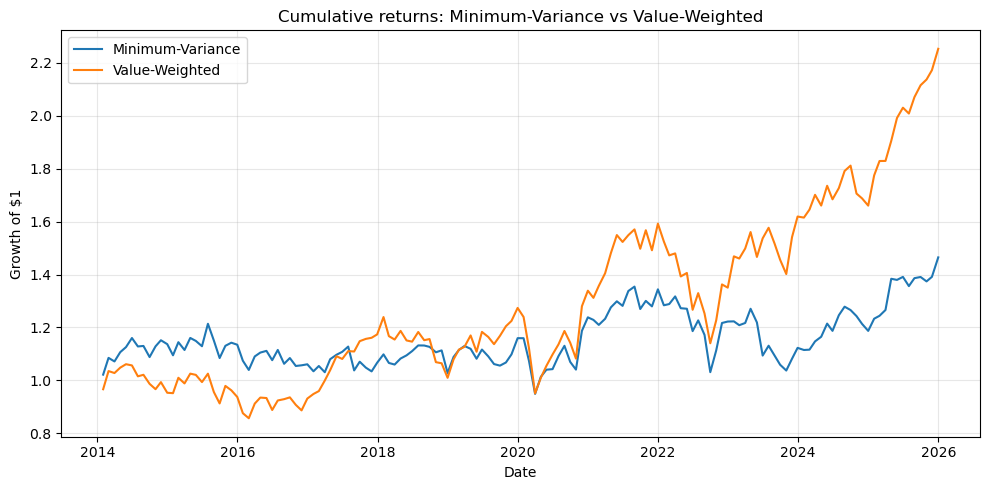

Done.
Outputs saved in: ..\results\outputs_vw

Return series check:
MV start: 2014-01-31 00:00:00
MV end:   2025-12-31 00:00:00
VW start: 2014-01-31 00:00:00
VW end:   2025-12-31 00:00:00
Number of months: 144

Summary statistics:
                  Annualized mean return  Annualized volatility  Sharpe ratio  Minimum monthly return  Maximum monthly return  Final cumulative index  Maximum drawdown  Number of monthly observations
Minimum-Variance                0.041307               0.137578      0.173147               -0.120155                0.140773                1.465024         -0.238762                           144.0
Value-Weighted                  0.080346               0.158463      0.397584               -0.152973                0.182863                2.253411         -0.283950                           144.0


In [37]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This cell assumes that Sections 2.1 and 2.2 have already been executed and that the required objects are available in memory
required_objects = [
    "years",
    "investment_sets",
    "year_end_dec",
    "ri_panel",
    "ret_panel",
    "mv_oos_returns",
    "rf_series"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")

data_dir = Path("../data/cleaned")
mv_file = data_dir / "MV_M_cleaned.csv"

output_dir = Path("../results/outputs_vw")
output_dir.mkdir(parents=True, exist_ok=True)

csv_sep = ";"

# Parse calendar date headers from the raw dataset
def parse_calendar_date_headers(columns):
    cols = pd.Index(columns).astype(str).str.strip()
    return [pd.to_datetime(c, dayfirst=True) for c in cols]

# Convert panel values to numeric format
def to_numeric_panel(df):
    return df.apply(
        lambda col: pd.to_numeric(
            col.astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )
    )

# Compute maximum drawdown from a cumulative return index
def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()

# Compute standard portfolio performance statistics
def perf_stats(r, rf):

    r = r.replace([np.inf, -np.inf], np.nan).dropna().copy()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned

    ann_mean = 12 * r_month.mean()
    ann_vol = np.sqrt(12) * r_month.std(ddof=1)

    if excess.std(ddof=1) != 0:
        sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
    else:
        sharpe = np.nan

    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": ann_mean,
        "Annualized volatility": ann_vol,
        "Sharpe ratio": sharpe,
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })

# Load monthly market capitalization data
mv_raw = pd.read_csv(mv_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

mv_dates = parse_calendar_date_headers(list(mv_raw.columns[2:]))

mv_panel = mv_raw.copy()
mv_panel.columns = ["NAME", "ISIN"] + mv_dates
mv_panel = mv_panel.set_index(["ISIN", "NAME"])

mv_panel = to_numeric_panel(mv_panel)

# Restrict the panel to the same sample period used in the project
mv_panel = mv_panel.loc[:, mv_panel.columns <= pd.Timestamp("2025-12-31")]

# Keep only firms already used in the previous sections
common_mv_firms = mv_panel.index.intersection(ret_panel.index).intersection(ri_panel.index)
mv_panel = mv_panel.loc[common_mv_firms]

print("Monthly market cap panel shape:", mv_panel.shape)

# Build the same delisting map used in Section 2.2
# If a firm is flagged as dead/delisted/suspended and the first missing RI observation appears after the last valid price, we assign a −100% return
delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
delist_event_month = {}

for asset in ri_panel.index:

    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date

vw_rows = []

all_months = sorted(ret_panel.columns)

# Construct the value-weighted portfolio returns
for Y in years:

    print(f"Formation year {Y} -> benchmark year {Y + 1}")

    eligible = investment_sets[Y]

    oos_months = [d for d in all_months if d.year == Y + 1]
    if len(oos_months) == 0:
        continue

    for dt in oos_months:

        current_loc = all_months.index(dt)
        prev_date = all_months[current_loc - 1]

        # Use previous-month market caps to compute portfolio weights
        caps_t = mv_panel.loc[eligible, prev_date].copy()
        r_t = ret_panel.loc[eligible, dt].copy()

        # Apply the same delisting treatment used in Section 2.2
        forced_delist_assets = []

        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        valid = (
            caps_t.notna()
            & np.isfinite(caps_t)
            & (caps_t > 0)
            & r_t.notna()
            & np.isfinite(r_t)
            & (r_t >= -1.0)
        )

        caps_t = caps_t[valid]
        r_t = r_t[valid]

        # Compute the value-weighted portfolio return
        if len(caps_t) == 0:
            port_ret = np.nan
        else:
            w_t = caps_t / caps_t.sum()
            port_ret = float((w_t * r_t).sum())

        vw_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": port_ret
        })

# Convert results into a time series of monthly returns
vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

if vw_monthly_returns.empty:
    raise ValueError("No value-weighted returns were produced.")

vw_monthly_returns["date"] = pd.to_datetime(vw_monthly_returns["date"])

# Restrict the final return series to the out-of-sample period
vw_monthly_returns = vw_monthly_returns[
    (vw_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (vw_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

vw_monthly_returns["cumulative_index"] = (1.0 + vw_monthly_returns["portfolio_return"]).cumprod()

vw_oos_returns = vw_monthly_returns.set_index("date")["portfolio_return"].sort_index()

# Combine minimum-variance and value-weighted returns
comparison_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        vw_oos_returns.rename("Value-Weighted")
    ],
    axis=1
).sort_index()

# Compute cumulative returns for both strategies
comparison_cumulative = (1.0 + comparison_returns).cumprod()

# Compute summary performance statistics
comparison_stats = pd.concat(
    [
        perf_stats(comparison_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        perf_stats(comparison_returns["Value-Weighted"], rf_series).rename("Value-Weighted")
    ],
    axis=1
).T

# Save the main output files
vw_monthly_returns.to_csv(output_dir / "vw_monthly_returns.csv", index=False)
comparison_returns.to_csv(output_dir / "comparison_monthly_returns.csv")
comparison_cumulative.to_csv(output_dir / "comparison_cumulative_returns.csv")
comparison_stats.to_csv(output_dir / "comparison_summary_stats.csv")

# Plot cumulative performance comparison
plt.figure(figsize=(10, 5))

plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Minimum-Variance"],
    label="Minimum-Variance"
)

plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Value-Weighted"],
    label="Value-Weighted"
)

plt.title("Cumulative returns: Minimum-Variance vs Value-Weighted")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

print("Done.")
print(f"Outputs saved in: {output_dir}")

print("\nReturn series check:")
print("MV start:", comparison_returns["Minimum-Variance"].dropna().index.min())
print("MV end:  ", comparison_returns["Minimum-Variance"].dropna().index.max())
print("VW start:", comparison_returns["Value-Weighted"].dropna().index.min())
print("VW end:  ", comparison_returns["Value-Weighted"].dropna().index.max())
print("Number of months:", comparison_returns.shape[0])

print("\nSummary statistics:")
print(comparison_stats.to_string())

### Interpretation of the results

The value-weighted portfolio delivers a higher annualized return and a higher Sharpe ratio than the minimum-variance portfolio over the **2014–2025** out-of-sample period. However, this improved performance comes with higher volatility and larger drawdowns.

By construction, the minimum-variance portfolio focuses on reducing total portfolio risk, which results in a smoother return path and smaller downside shocks. This can be observed in the lower annualized volatility and the smaller minimum monthly return compared to the value-weighted benchmark.

Overall, the results highlight the classic trade-off between risk reduction and return generation: while the minimum-variance strategy produces more stable returns, the value-weighted portfolio captures a larger share of market upside during the sample period.

## **Part II - Portfolio Allocation with Carbon Emission Reduction**
